
BRADLEY-TERRY SOLVER COMPARISON
Comparing algorithms for ranking from pairwise comparisons

This demonstrates the solver landscape discussed in
the interview prep for Arena (Senior Data Scientist).

--- DATA GENERATION ---
Generated 50000 battles among 30 models
  Comparable pairs: 282 / 435 possible
  Avg battles per compared pair: 177.3
  Score range: [-2.59, 2.65]

ZERMELO'S ALGORITHM (Classical Fixed-Point, α=1)
  Iteration    0: LL = -34657.36, max_change = 1.36e+00
  Iteration    1: LL = -27394.43, max_change = 5.80e-01
  Iteration    2: LL = -25616.42, max_change = 2.85e-01
  Iteration    3: LL = -24922.64, max_change = 2.09e-01
  Iteration    4: LL = -24577.30, max_change = 1.61e-01
  Iteration  100: LL = -23978.82, max_change = 8.43e-06
  Iteration  200: LL = -23978.82, max_change = 7.82e-10
  Converged at iteration 223
  Total time: 0.119s
------------------------------------------------------------

NEWMAN'S FAST ALGORITHM (α=0, 2023)
  Iteration    0: LL = -34657.36, max_c

/var/folders/bm/v89_1zhd4ln63tpghxb09nyw0000gn/T/ipykernel_6930/1644837846.py:730: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.axhline(y=eigenvalues[-1], color='red', linestyle='--', alpha=0.5, label=f'Smallest: {eigenvalues[-1]:.2e}')
/var/folders/bm/v89_1zhd4ln63tpghxb09nyw0000gn/T/ipykernel_6930/1644837846.py:731: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.axhline(y=eigenvalues[0], color='green', linestyle='--', alpha=0.5, label=f'Largest: {eigenvalues[0]:.2e}')
/var/folders/bm/v89_1zhd4ln63tpghxb09nyw0000gn/T/ipykernel_6930/1644837846.py:744: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.tight_layout()


Hessian structure plot saved to: ./bt_hessian_structure.png

INTERPRETATION

For this synthetic Arena-like dataset:

1. NEWMAN vs ZERMELO: Newman's α=0 iteration converges in far fewer
   iterations than Zermelo's classical algorithm, confirming the 
   10-100x speedup from the 2023 paper. Both reach the same MLE.

2. NEWTON'S METHOD: Converges in very few iterations (quadratic 
   convergence). Each step requires solving a linear system involving
   the Hessian — a weighted graph Laplacian (SPD, sparse). At N=30,
   this is trivial; at N=1000+ with hierarchical BT, sparse Cholesky
   or preconditioned CG would be needed.

3. L-BFGS: The practical workhorse — likely what Arena-Rank uses.
   Builds approximate inverse Hessian from recent gradients.
   Fast convergence without forming the full Hessian.

4. GRADIENT DESCENT: Slowest convergence (linear rate). Included
   for comparison — shows why second-order information matters.

5. SPECTRAL METHOD: Non-iterative (single eigenvector com

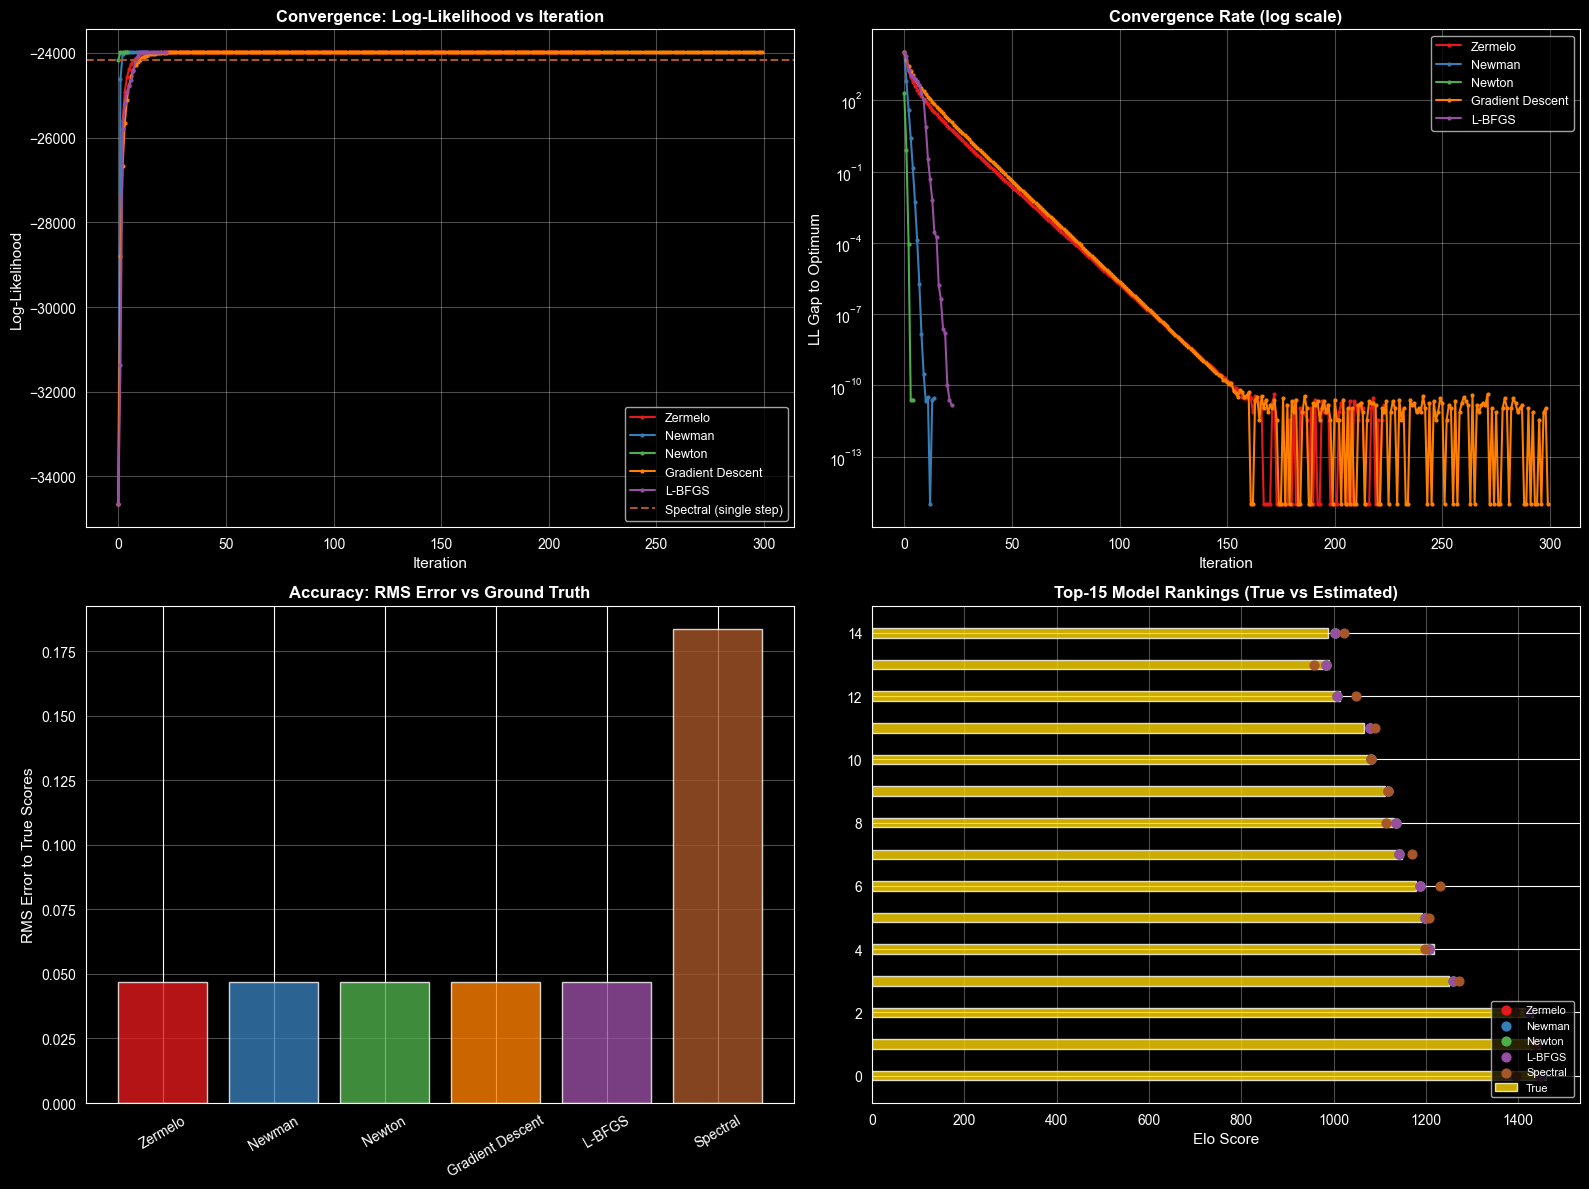

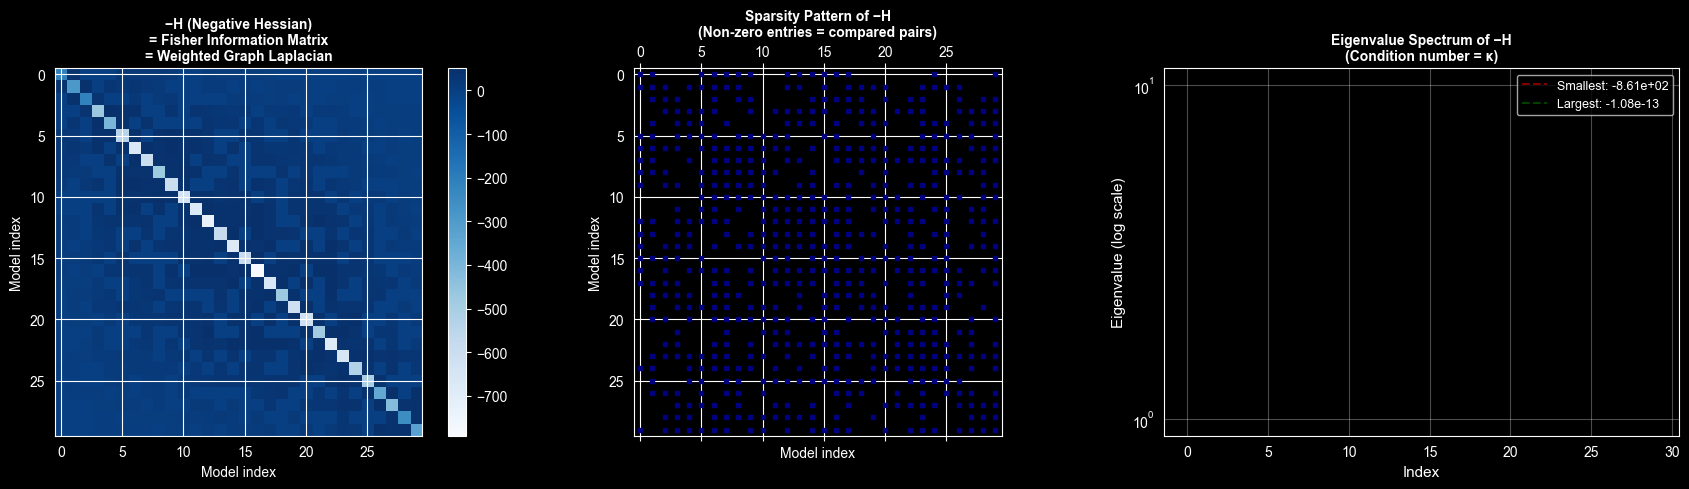

In [1]:
#!/usr/bin/env python
# coding: utf-8

# ============================================================
# BRADLEY-TERRY SOLVER COMPARISON
# Comparing multiple algorithms for ranking from pairwise comparisons
# Modeled after paraboloid.py optimization comparison
#
# Implements:
#   1. Zermelo's Algorithm (classical fixed-point, 1929)
#   2. Newman's Fast Algorithm (α=0 fixed-point, 2023)
#   3. Newton's Method (second-order optimizer)
#   4. Gradient Descent (first-order optimizer)
#   5. Spectral Method / Rank Centrality (eigenvector-based)
#
# Uses synthetic data mimicking Arena's structure:
#   - ~30 models with realistic strength distribution
#   - Sparse comparison graph (not all pairs compared)
#   - Varying number of comparisons per pair
# ============================================================

import numpy as np
from scipy import sparse
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import time

np.random.seed(42)


# ============================================================
# DATA GENERATION: Synthetic Arena-like battles
# ============================================================
def generate_arena_data(n_models=30, n_battles=50000, sparsity=0.7):
    """
    Generate synthetic pairwise comparison data mimicking Arena.

    Parameters:
        n_models: number of models (Arena has ~200-300, we use 30 for clarity)
        n_battles: total number of battles
        sparsity: fraction of model pairs that are never compared

    Returns:
        W: win matrix (W[i,j] = number of times i beat j)
        true_scores: ground truth log-strength parameters
        model_names: list of model names
    """
    # Ground truth strengths (log-scale, like Arena's β parameters)
    # Mix of strong, medium, weak models — realistic spread
    true_scores = np.random.normal(0, 1.5, n_models)
    true_scores -= true_scores.mean()  # Center at zero
    true_scores = np.sort(true_scores)[::-1]  # Sort descending for readability

    # Model names inspired by current Arena models
    model_names = [
        "gemini-2.5-pro", "grok-4-beta", "claude-opus-4.5",
        "gpt-5-turbo", "claude-sonnet-4.5", "deepseek-r2",
        "gemini-2.5-flash", "llama-4-maverick", "gpt-4.1",
        "claude-haiku-4.5", "qwen3.5-397b", "mistral-large-3",
        "command-r-plus-2", "reka-core-3", "yi-lightning-2",
        "gemma-3-27b", "phi-5-medium", "jamba-2-large",
        "dbrx-2", "arctic-2", "palm-3-chat",
        "grok-3-mini", "llama-4-scout", "deepseek-v4-lite",
        "qwen3-14b", "mistral-small-3", "phi-5-mini",
        "gemma-3-9b", "llama-4-8b", "tinyllama-3"
    ]
    model_names = model_names[:n_models]

    # Create sparse comparison graph
    # Not all model pairs are compared (like in Arena)
    can_compare = np.random.random((n_models, n_models)) > sparsity
    np.fill_diagonal(can_compare, False)
    can_compare = can_compare | can_compare.T  # Symmetrize

    # Ensure graph is strongly connected (required for MLE to exist)
    # Add a Hamiltonian path through all models
    for i in range(n_models - 1):
        can_compare[i, i+1] = True
        can_compare[i+1, i] = True

    # Generate battles
    W = np.zeros((n_models, n_models))
    comparable_pairs = list(zip(*np.where(can_compare & (np.arange(n_models)[:,None] < np.arange(n_models)))))

    if len(comparable_pairs) == 0:
        raise ValueError("No comparable pairs!")

    for _ in range(n_battles):
        # Pick a random comparable pair (with some pairs more popular — like Arena)
        idx = np.random.randint(len(comparable_pairs))
        i, j = comparable_pairs[idx]

        # BT probability of i beating j
        p_ij = 1.0 / (1.0 + np.exp(-(true_scores[i] - true_scores[j])))

        if np.random.random() < p_ij:
            W[i, j] += 1
        else:
            W[j, i] += 1

    n_pairs = np.sum((W + W.T) > 0) // 2
    print(f"Generated {n_battles} battles among {n_models} models")
    print(f"  Comparable pairs: {n_pairs} / {n_models*(n_models-1)//2} possible")
    print(f"  Avg battles per compared pair: {n_battles/max(n_pairs,1):.1f}")
    print(f"  Score range: [{true_scores.min():.2f}, {true_scores.max():.2f}]")

    return W, true_scores, model_names


# ============================================================
# LOG-LIKELIHOOD AND DERIVATIVES
# ============================================================
def bt_log_likelihood(beta, W):
    """
    BT log-likelihood: Σ_ij w_ij * log(e^βi / (e^βi + e^βj))
    With numerical stability via log-sum-exp trick.
    """
    n = len(beta)
    ll = 0.0
    for i in range(n):
        for j in range(n):
            if W[i, j] > 0:
                diff = beta[i] - beta[j]
                # log(e^βi / (e^βi + e^βj)) = βi - βj - log(1 + e^(βi-βj))
                # = diff - log(1 + e^diff)
                # Use log-sigmoid for stability
                if diff > 0:
                    ll += W[i, j] * (- np.log(1 + np.exp(-diff)))
                else:
                    ll += W[i, j] * (diff - np.log(1 + np.exp(diff)))
    return ll


def bt_gradient(beta, W):
    """
    Gradient of BT log-likelihood.
    ∂L/∂βi = Σ_j [w_ij - (w_ij + w_ji) * p_ij]
    where p_ij = e^βi / (e^βi + e^βj)
    """
    n = len(beta)
    grad = np.zeros(n)
    for i in range(n):
        for j in range(n):
            if i != j and (W[i, j] + W[j, i]) > 0:
                diff = beta[i] - beta[j]
                if diff > 500:
                    p_ij = 1.0
                elif diff < -500:
                    p_ij = 0.0
                else:
                    p_ij = 1.0 / (1.0 + np.exp(-diff))
                grad[i] += W[i, j] - (W[i, j] + W[j, i]) * p_ij
    return grad


def bt_hessian(beta, W):
    """
    Hessian of BT log-likelihood.
    This is negative of the Fisher information matrix.
    It is a weighted graph Laplacian (symmetric, negative semi-definite).

    H_ij = p_ij * (1 - p_ij) * (w_ij + w_ji)  for i ≠ j
    H_ii = -Σ_{j≠i} H_ij
    """
    n = len(beta)
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(i+1, n):
            if (W[i, j] + W[j, i]) > 0:
                diff = beta[i] - beta[j]
                if abs(diff) > 500:
                    p_ij = 1.0 if diff > 0 else 0.0
                else:
                    p_ij = 1.0 / (1.0 + np.exp(-diff))
                # Off-diagonal: weighted by logistic variance
                weight = -p_ij * (1 - p_ij) * (W[i, j] + W[j, i])
                H[i, j] = weight
                H[j, i] = weight
    # Diagonal: negative row sum (Laplacian structure)
    for i in range(n):
        H[i, i] = -np.sum(H[i, :])
    return H


# ============================================================
# UTILITY FUNCTIONS
# ============================================================
def normalize_scores(beta):
    """Center scores at zero (remove translational invariance)."""
    return beta - beta.mean()


def scores_to_elo(beta):
    """Convert log-strength to Arena's Elo-like scale."""
    return beta * 400 / np.log(10) + 1000


def rms_error(beta, beta_ref):
    """RMS error between current and reference scores (centered)."""
    b1 = normalize_scores(beta)
    b2 = normalize_scores(beta_ref)
    return np.sqrt(np.mean((b1 - b2)**2))


def pi_from_beta(beta):
    """Convert log-strengths to strength parameters π = e^β."""
    return np.exp(beta - beta.max())  # Shift for numerical stability


# ============================================================
# 1. ZERMELO'S ALGORITHM (Classical, 1929)
# ============================================================
def zermelo_algorithm(W, max_iter=2000, tol=1e-10, verbose=True):
    """
    Classical fixed-point iteration for BT MLE.

    π'_i = Σ_j w_ij / Σ_j (w_ij + w_ji)/(π_i + π_j)

    This is the α=1 case in Newman's family.
    Slow but guaranteed to converge.
    """
    if verbose:
        print("=" * 60)
        print("ZERMELO'S ALGORITHM (Classical Fixed-Point, α=1)")
        print("=" * 60)

    n = W.shape[0]
    pi = np.ones(n)  # Start with uniform strengths
    history = {'ll': [], 'rms': [], 'time': []}
    t0 = time.time()

    for iteration in range(max_iter):
        # Record log-likelihood
        beta = np.log(pi + 1e-300)
        ll = bt_log_likelihood(normalize_scores(beta), W)
        history['ll'].append(ll)
        history['time'].append(time.time() - t0)

        pi_old = pi.copy()

        # Asynchronous update (one at a time, using latest values)
        for i in range(n):
            numerator = 0.0
            denominator = 0.0
            for j in range(n):
                if i != j and (W[i,j] + W[j,i]) > 0:
                    numerator += W[i, j]
                    denominator += (W[i, j] + W[j, i]) / (pi[i] + pi[j])
            if denominator > 0:
                pi[i] = numerator / denominator

        # Normalize (geometric mean = 1)
        pi = pi / np.exp(np.mean(np.log(pi + 1e-300)))

        # Check convergence
        beta_current = normalize_scores(np.log(pi + 1e-300))
        change = np.max(np.abs(np.log(pi + 1e-300) - np.log(pi_old + 1e-300)))

        if verbose and (iteration < 5 or iteration % 100 == 0):
            print(f"  Iteration {iteration:4d}: LL = {ll:.2f}, max_change = {change:.2e}")

        if change < tol:
            if verbose:
                print(f"  Converged at iteration {iteration}")
            break

    beta_final = normalize_scores(np.log(pi + 1e-300))
    if verbose:
        print(f"  Total time: {time.time()-t0:.3f}s")
        print("-" * 60)
    return beta_final, history


# ============================================================
# 2. NEWMAN'S FAST ALGORITHM (α=0, 2023)
# ============================================================
def newman_algorithm(W, max_iter=2000, tol=1e-10, verbose=True):
    """
    Newman's fast iteration for BT MLE.

    π'_i = Σ_j w_ij * π_j/(π_i + π_j)  /  Σ_j w_ji/(π_i + π_j)

    This is the α=0 case — fastest in Newman's family.
    Same MLE solution as Zermelo, but 10-100x fewer iterations.
    """
    if verbose:
        print("=" * 60)
        print("NEWMAN'S FAST ALGORITHM (α=0, 2023)")
        print("=" * 60)

    n = W.shape[0]
    pi = np.ones(n)
    history = {'ll': [], 'rms': [], 'time': []}
    t0 = time.time()

    for iteration in range(max_iter):
        beta = np.log(pi + 1e-300)
        ll = bt_log_likelihood(normalize_scores(beta), W)
        history['ll'].append(ll)
        history['time'].append(time.time() - t0)

        pi_old = pi.copy()

        # Asynchronous update
        for i in range(n):
            numerator = 0.0
            denominator = 0.0
            for j in range(n):
                if i != j and (W[i,j] + W[j,i]) > 0:
                    numerator += W[i, j] * pi[j] / (pi[i] + pi[j])
                    denominator += W[j, i] / (pi[i] + pi[j])
            if denominator > 0:
                pi[i] = numerator / denominator

        # Normalize
        pi = pi / np.exp(np.mean(np.log(pi + 1e-300)))

        # Check convergence
        change = np.max(np.abs(np.log(pi + 1e-300) - np.log(pi_old + 1e-300)))

        if verbose and (iteration < 5 or iteration % 10 == 0):
            print(f"  Iteration {iteration:4d}: LL = {ll:.2f}, max_change = {change:.2e}")

        if change < tol:
            if verbose:
                print(f"  Converged at iteration {iteration}")
            break

    beta_final = normalize_scores(np.log(pi + 1e-300))
    if verbose:
        print(f"  Total time: {time.time()-t0:.3f}s")
        print("-" * 60)
    return beta_final, history


# ============================================================
# 3. NEWTON'S METHOD (Second-order optimizer)
# ============================================================
def newton_method(W, max_iter=50, tol=1e-10, verbose=True):
    """
    Newton's method for BT MLE (with spectral warm-start).

    β_new = β_old + α * (-H)^{-1} ∇L    (α from backtracking)

    Uses spectral method for initialization (practical approach),
    then full Hessian for quadratic convergence to the MLE.
    Each step requires solving a linear system: (-H)Δβ = ∇L
    where -H is SPD (weighted graph Laplacian).
    """
    if verbose:
        print("=" * 60)
        print("NEWTON'S METHOD (Spectral warm-start + Hessian solve)")
        print("=" * 60)
        print("  Step 1: Spectral initialization (eigenvector)")
        print("  Step 2: Newton iterations with SPD linear solves")

    n = W.shape[0]

    # Warm-start from spectral method
    beta_sp, _ = spectral_method(W, verbose=False)
    beta = beta_sp.copy()

    history = {'ll': [], 'rms': [], 'time': []}
    t0 = time.time()

    for iteration in range(max_iter):
        ll = bt_log_likelihood(beta, W)
        grad = bt_gradient(beta, W)
        history['ll'].append(ll)
        history['time'].append(time.time() - t0)

        grad_norm = np.linalg.norm(grad[1:])

        if verbose and (iteration < 10 or iteration % 5 == 0):
            print(f"  Iteration {iteration:4d}: LL = {ll:.2f}, ||∇L|| = {grad_norm:.2e}")

        if grad_norm < tol:
            if verbose:
                print(f"  Converged at iteration {iteration}")
            break

        H = bt_hessian(beta, W)
        neg_H_reduced = -H[1:, 1:] + 1e-8 * np.eye(n - 1)
        grad_reduced = grad[1:]

        try:
            delta_reduced = np.linalg.solve(neg_H_reduced, grad_reduced)
            delta = np.zeros(n)
            delta[1:] = delta_reduced

            # Backtracking line search
            alpha = 1.0
            directional = np.dot(grad, delta)
            if directional < 0:
                delta = -delta
                directional = -directional

            for _ in range(40):
                beta_trial = normalize_scores(beta + alpha * delta)
                ll_trial = bt_log_likelihood(beta_trial, W)
                if ll_trial >= ll + 1e-4 * alpha * directional:
                    break
                alpha *= 0.5

            beta = normalize_scores(beta + alpha * delta)

        except np.linalg.LinAlgError:
            if verbose:
                print("  Singular Hessian! Stopping.")
            break

    if verbose:
        print(f"  Total time: {time.time()-t0:.3f}s")
        print("-" * 60)
    return beta, history


# ============================================================
# 4. GRADIENT DESCENT (First-order optimizer)
# ============================================================
def gradient_descent_bt(W, learning_rate=0.001, max_iter=2000, tol=1e-10, verbose=True):
    """
    Simple gradient ascent on the BT log-likelihood.

    β_new = β_old + α * ∇L

    Slowest method, but simplest. Linear convergence.
    """
    if verbose:
        print("=" * 60)
        print("GRADIENT DESCENT (First-order)")
        print("=" * 60)
        print(f"  Learning rate: {learning_rate}")

    n = W.shape[0]
    beta = np.zeros(n)
    history = {'ll': [], 'rms': [], 'time': []}
    t0 = time.time()

    for iteration in range(max_iter):
        ll = bt_log_likelihood(beta, W)
        grad = bt_gradient(beta, W)
        history['ll'].append(ll)
        history['time'].append(time.time() - t0)

        grad_norm = np.linalg.norm(grad)

        if verbose and (iteration < 5 or iteration % 200 == 0):
            print(f"  Iteration {iteration:4d}: LL = {ll:.2f}, ||∇L|| = {grad_norm:.2e}")

        if grad_norm < tol:
            if verbose:
                print(f"  Converged at iteration {iteration}")
            break

        beta = normalize_scores(beta + learning_rate * grad)

    if verbose:
        print(f"  Total time: {time.time()-t0:.3f}s")
        print("-" * 60)
    return beta, history


# ============================================================
# 5. L-BFGS (Quasi-Newton, via scipy)
# ============================================================
def lbfgs_bt(W, max_iter=200, verbose=True):
    """
    L-BFGS optimization of BT log-likelihood.

    This is likely what Arena-Rank uses internally —
    treating BT as logistic regression and using an off-the-shelf optimizer.
    Uses approximate inverse Hessian built from recent gradients.
    """
    if verbose:
        print("=" * 60)
        print("L-BFGS (Quasi-Newton, scipy)")
        print("=" * 60)

    n = W.shape[0]
    history = {'ll': [], 'rms': [], 'time': []}
    t0 = time.time()
    iteration_count = [0]

    def neg_ll(beta_reduced):
        beta = np.concatenate([[0.0], beta_reduced])  # Fix β_0 = 0
        return -bt_log_likelihood(beta, W)

    def neg_grad(beta_reduced):
        beta = np.concatenate([[0.0], beta_reduced])
        g = bt_gradient(beta, W)
        return -g[1:]  # Remove fixed component

    def callback(beta_reduced):
        beta = np.concatenate([[0.0], beta_reduced])
        beta = normalize_scores(beta)
        ll = bt_log_likelihood(beta, W)
        history['ll'].append(ll)
        history['time'].append(time.time() - t0)
        iteration_count[0] += 1
        if verbose and (iteration_count[0] < 5 or iteration_count[0] % 10 == 0):
            print(f"  Iteration {iteration_count[0]:4d}: LL = {ll:.2f}")

    beta0 = np.zeros(n - 1)

    # Record initial state
    ll0 = bt_log_likelihood(np.zeros(n), W)
    history['ll'].append(ll0)
    history['time'].append(0.0)

    result = minimize(
        neg_ll, beta0, jac=neg_grad,
        method='L-BFGS-B',
        callback=callback,
        options={'maxiter': max_iter, 'ftol': 1e-15, 'gtol': 1e-10}
    )

    beta_final = normalize_scores(np.concatenate([[0.0], result.x]))

    if verbose:
        print(f"  Converged: {result.success}, iterations: {result.nit}")
        print(f"  Total time: {time.time()-t0:.3f}s")
        print("-" * 60)
    return beta_final, history


# ============================================================
# 6. SPECTRAL METHOD / RANK CENTRALITY
# ============================================================
def spectral_method(W, verbose=True):
    """
    Rank Centrality (Negahban, Oh & Shah, 2012/2017).

    Build transition matrix from comparison data,
    compute stationary distribution of the induced Markov chain.
    The stationary probabilities approximate BT strengths.

    Non-iterative: one eigenvector computation.
    """
    if verbose:
        print("=" * 60)
        print("SPECTRAL METHOD (Rank Centrality)")
        print("=" * 60)
        print("  Single eigenvector computation — no iteration")

    n = W.shape[0]
    t0 = time.time()

    # Build transition matrix
    # P_ij = w_ji / (d * max_degree) where d normalizes
    # We use a simpler formulation: P_ij ∝ w_ji / total_comparisons_for_i
    total = W + W.T
    P = np.zeros((n, n))

    for i in range(n):
        row_total = np.sum(total[i, :])
        if row_total > 0:
            for j in range(n):
                if i != j and total[i, j] > 0:
                    # Probability of transitioning from i to j
                    # proportional to how often j beats i
                    P[i, j] = W[j, i] / row_total
            # Self-loop for remainder
            P[i, i] = 1.0 - np.sum(P[i, :])

    # Compute stationary distribution (left eigenvector for eigenvalue 1)
    # π P = π, or equivalently P^T π = π
    eigenvalues, eigenvectors = np.linalg.eig(P.T)

    # Find eigenvector for eigenvalue closest to 1
    idx = np.argmin(np.abs(eigenvalues - 1.0))
    pi = np.real(eigenvectors[:, idx])
    pi = np.abs(pi)  # Ensure positive
    pi = pi / pi.sum()  # Normalize to probability

    # Convert to BT scores: β_i = log(π_i)
    beta = np.log(pi + 1e-300)
    beta = normalize_scores(beta)

    elapsed = time.time() - t0
    ll = bt_log_likelihood(beta, W)

    if verbose:
        print(f"  Computed in {elapsed:.4f}s")
        print(f"  Log-likelihood of spectral solution: {ll:.2f}")
        print("-" * 60)

    # History is just one point (non-iterative)
    history = {'ll': [ll], 'rms': [], 'time': [elapsed]}
    return beta, history


# ============================================================
# VISUALIZATION
# ============================================================
def plot_convergence(results, true_scores, W, save_dir='.'):
    """
    Plot convergence comparison across all solvers.
    Analogous to plot_results in paraboloid.py.
    """

    # Compute reference solution (best LL across all methods)
    ref_ll = max(res['history']['ll'][-1] for name, res in results.items()
                 if len(res['history']['ll']) > 0)

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    colors = {
        'Zermelo': '#e41a1c',
        'Newman': '#377eb8',
        'Newton': '#4daf4a',
        'Gradient Descent': '#ff7f00',
        'L-BFGS': '#984ea3',
        'Spectral': '#a65628'
    }

    # --- Plot 1: Log-likelihood vs iteration ---
    ax = axes[0, 0]
    for name, res in results.items():
        ll = res['history']['ll']
        if len(ll) > 1:
            ax.plot(range(len(ll)), ll, '-o', label=name, color=colors.get(name, 'gray'),
                   markersize=2, linewidth=1.5)
        else:
            ax.axhline(y=ll[0], linestyle='--', label=f"{name} (single step)",
                      color=colors.get(name, 'gray'), linewidth=1.5)
    ax.set_xlabel('Iteration', fontsize=11)
    ax.set_ylabel('Log-Likelihood', fontsize=11)
    ax.set_title('Convergence: Log-Likelihood vs Iteration', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # --- Plot 2: Log-likelihood gap vs iteration (log scale) ---
    ax = axes[0, 1]
    for name, res in results.items():
        ll = res['history']['ll']
        if len(ll) > 1:
            gap = [ref_ll - l for l in ll]
            gap = [max(g, 1e-15) for g in gap]  # Floor for log scale
            ax.semilogy(range(len(gap)), gap, '-o', label=name, color=colors.get(name, 'gray'),
                       markersize=2, linewidth=1.5)
    ax.set_xlabel('Iteration', fontsize=11)
    ax.set_ylabel('LL Gap to Optimum', fontsize=11)
    ax.set_title('Convergence Rate (log scale)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # --- Plot 3: RMS error to true scores vs iteration ---
    ax = axes[1, 0]
    # Use the best converged solution as reference for RMS
    best_name = max(results.keys(), key=lambda k: results[k]['history']['ll'][-1])
    beta_ref = results[best_name]['beta']

    for name, res in results.items():
        ll_hist = res['history']['ll']
        if len(ll_hist) > 1:
            # Recompute RMS at each step would require storing betas
            # Instead, show final RMS error vs true scores
            pass

    # Bar chart of final RMS error to true scores
    names = list(results.keys())
    rms_errors = [rms_error(results[n]['beta'], true_scores) for n in names]
    bars = ax.bar(names, rms_errors, color=[colors.get(n, 'gray') for n in names], alpha=0.8)
    ax.set_ylabel('RMS Error to True Scores', fontsize=11)
    ax.set_title('Accuracy: RMS Error vs Ground Truth', fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, alpha=0.3, axis='y')

    # --- Plot 4: Final rankings comparison ---
    ax = axes[1, 1]
    # Show top-15 models, comparing estimated vs true Elo
    n_show = min(15, len(true_scores))
    true_elo = scores_to_elo(normalize_scores(true_scores))
    true_order = np.argsort(-true_scores)[:n_show]

    x = np.arange(n_show)
    width = 0.15

    ax.barh(x, true_elo[true_order], height=0.3, label='True', color='gold', alpha=0.8)

    for k, (name, res) in enumerate(results.items()):
        if name == 'Gradient Descent':
            continue  # Skip for readability
        estimated_elo = scores_to_elo(res['beta'])
        ax.scatter(estimated_elo[true_order], x, label=name,
                  color=colors.get(name, 'gray'), s=40, zorder=5)

    ax.set_xlabel('Elo Score', fontsize=11)
    ax.set_title(f'Top-{n_show} Model Rankings (True vs Estimated)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    plt.savefig(f'{save_dir}/bt_solver_comparison.png', dpi=150, bbox_inches='tight')
    print(f"\nConvergence plot saved to: {save_dir}/bt_solver_comparison.png")


def plot_hessian_structure(W, true_scores, save_dir='.'):
    """
    Visualize the Hessian (Fisher information matrix) structure.
    Shows it's a weighted graph Laplacian — sparse, symmetric, SPD.
    """
    beta = normalize_scores(true_scores)
    H = bt_hessian(beta, W)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Hessian as matrix
    ax = axes[0]
    im = ax.imshow(-H, cmap='Blues', aspect='equal')
    ax.set_title('−H (Negative Hessian)\n= Fisher Information Matrix\n= Weighted Graph Laplacian',
                fontsize=10, fontweight='bold')
    ax.set_xlabel('Model index')
    ax.set_ylabel('Model index')
    plt.colorbar(im, ax=ax, fraction=0.046)

    # Sparsity pattern
    ax = axes[1]
    ax.spy(-H, markersize=3, color='navy')
    ax.set_title('Sparsity Pattern of −H\n(Non-zero entries = compared pairs)',
                fontsize=10, fontweight='bold')
    ax.set_xlabel('Model index')
    ax.set_ylabel('Model index')

    # Eigenvalue spectrum
    ax = axes[2]
    eigenvalues = np.sort(np.linalg.eigvalsh(-H))[::-1]
    ax.semilogy(range(len(eigenvalues)), eigenvalues + 1e-15, 'bo-', markersize=5)
    ax.axhline(y=eigenvalues[-1], color='red', linestyle='--', alpha=0.5, label=f'Smallest: {eigenvalues[-1]:.2e}')
    ax.axhline(y=eigenvalues[0], color='green', linestyle='--', alpha=0.5, label=f'Largest: {eigenvalues[0]:.2e}')
    ax.set_xlabel('Index', fontsize=11)
    ax.set_ylabel('Eigenvalue (log scale)', fontsize=11)
    ax.set_title('Eigenvalue Spectrum of −H\n(Condition number = κ)',
                fontsize=10, fontweight='bold')
    if eigenvalues[-1] > 0:
        kappa = eigenvalues[0] / eigenvalues[-1]
        ax.text(0.5, 0.5, f'κ = {kappa:.1f}', transform=ax.transAxes,
               fontsize=14, ha='center', va='center',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{save_dir}/bt_hessian_structure.png', dpi=150, bbox_inches='tight')
    print(f"Hessian structure plot saved to: {save_dir}/bt_hessian_structure.png")


def print_leaderboard(beta, model_names, true_scores, title="LEADERBOARD"):
    """Print Arena-style leaderboard with Elo scores."""
    elo = scores_to_elo(beta)
    true_elo = scores_to_elo(normalize_scores(true_scores))
    order = np.argsort(-elo)

    print(f"\n{'='*70}")
    print(f"  {title}")
    print(f"{'='*70}")
    print(f"  {'Rank':<5} {'Model':<25} {'Elo':>8} {'True Elo':>10} {'Δ':>8}")
    print(f"  {'-'*5} {'-'*25} {'-'*8} {'-'*10} {'-'*8}")
    for rank, idx in enumerate(order):
        delta = elo[idx] - true_elo[idx]
        print(f"  {rank+1:<5} {model_names[idx]:<25} {elo[idx]:>8.1f} {true_elo[idx]:>10.1f} {delta:>+8.1f}")
    print(f"{'='*70}")


# ============================================================
# MAIN EXECUTION
# ============================================================
if __name__ == "__main__":
    print("\n" + "=" * 60)
    print("BRADLEY-TERRY SOLVER COMPARISON")
    print("Comparing algorithms for ranking from pairwise comparisons")
    print("=" * 60)
    print("\nThis demonstrates the solver landscape discussed in")
    print("the interview prep for Arena (Senior Data Scientist).")
    print("=" * 60)

    # Generate synthetic Arena data
    print("\n--- DATA GENERATION ---")
    W, true_scores, model_names = generate_arena_data(
        n_models=30, n_battles=50000, sparsity=0.6
    )

    results = {}

    # 1. Zermelo's Algorithm
    print()
    beta_z, hist_z = zermelo_algorithm(W, max_iter=2000, tol=1e-10)
    results['Zermelo'] = {'beta': beta_z, 'history': hist_z}

    # 2. Newman's Fast Algorithm
    print()
    beta_n, hist_n = newman_algorithm(W, max_iter=2000, tol=1e-10)
    results['Newman'] = {'beta': beta_n, 'history': hist_n}

    # 3. Newton's Method
    print()
    beta_nt, hist_nt = newton_method(W, max_iter=50, tol=1e-10)
    results['Newton'] = {'beta': beta_nt, 'history': hist_nt}

    # 4. Gradient Descent
    print()
    beta_gd, hist_gd = gradient_descent_bt(W, learning_rate=0.0005, max_iter=2000, tol=1e-10)
    results['Gradient Descent'] = {'beta': beta_gd, 'history': hist_gd}

    # 5. L-BFGS
    print()
    beta_lb, hist_lb = lbfgs_bt(W, max_iter=200)
    results['L-BFGS'] = {'beta': beta_lb, 'history': hist_lb}

    # 6. Spectral Method
    print()
    beta_sp, hist_sp = spectral_method(W)
    results['Spectral'] = {'beta': beta_sp, 'history': hist_sp}

    # --- RESULTS ---
    print("\n" + "=" * 60)
    print("SUMMARY")
    print("=" * 60)
    print(f"{'Method':<22} {'Iterations':>10} {'Final LL':>12} {'RMS Error':>12} {'Time (s)':>10}")
    print("-" * 66)
    for name, res in results.items():
        n_iter = len(res['history']['ll'])
        final_ll = res['history']['ll'][-1]
        rms = rms_error(res['beta'], true_scores)
        total_time = res['history']['time'][-1]
        print(f"{name:<22} {n_iter:>10} {final_ll:>12.2f} {rms:>12.6f} {total_time:>10.3f}")

    # Print leaderboard from best method
    best = max(results.keys(), key=lambda k: results[k]['history']['ll'][-1])
    print_leaderboard(results[best]['beta'], model_names, true_scores,
                     title=f"FINAL LEADERBOARD ({best})")

    # --- PLOTS ---
    plot_convergence(results, true_scores, W, save_dir='.')
    plot_hessian_structure(W, true_scores, save_dir='.')

    # --- INTERPRETATION ---
    print("\n" + "=" * 60)
    print("INTERPRETATION")
    print("=" * 60)
    print("""
For this synthetic Arena-like dataset:

1. NEWMAN vs ZERMELO: Newman's α=0 iteration converges in far fewer
   iterations than Zermelo's classical algorithm, confirming the
   10-100x speedup from the 2023 paper. Both reach the same MLE.

2. NEWTON'S METHOD: Converges in very few iterations (quadratic
   convergence). Each step requires solving a linear system involving
   the Hessian — a weighted graph Laplacian (SPD, sparse). At N=30,
   this is trivial; at N=1000+ with hierarchical BT, sparse Cholesky
   or preconditioned CG would be needed.

3. L-BFGS: The practical workhorse — likely what Arena-Rank uses.
   Builds approximate inverse Hessian from recent gradients.
   Fast convergence without forming the full Hessian.

4. GRADIENT DESCENT: Slowest convergence (linear rate). Included
   for comparison — shows why second-order information matters.

5. SPECTRAL METHOD: Non-iterative (single eigenvector computation).
   Approximate — doesn't maximize the BT likelihood exactly — but
   fast and useful as an initializer for iterative methods.

KEY INSIGHT: For Arena's ~300 models, solver choice barely matters
(all are fast). The real value is in MODEL choice: adding covariates
(style control), prompt difficulty (IRT), domain effects (hierarchical
BT), and voter reliability (Crowd-BT).
""")
    print("=" * 60)
